EXERCISE 13: PENDULUM ODE
Equation: d²θ/dx² + 3*sin(θ) = 0
Initial conditions: θ(0) = 1.0, dθ/dx(0) = 0.0
Solution interval: x ∈ [0.0, 10.0]

Generating solutions...
  - Euler method with 1000 steps
  - Euler method with 10000 steps
  - RK3 method with 100 steps
Done!

FINAL VALUES AT x = 10.0

Euler (1000 steps):  θ(10) = -1.0741367801
Euler (10000 steps): θ(10) = -0.8848922418
RK3 (100 steps):     θ(10) = -0.8606865827

Generating plots...


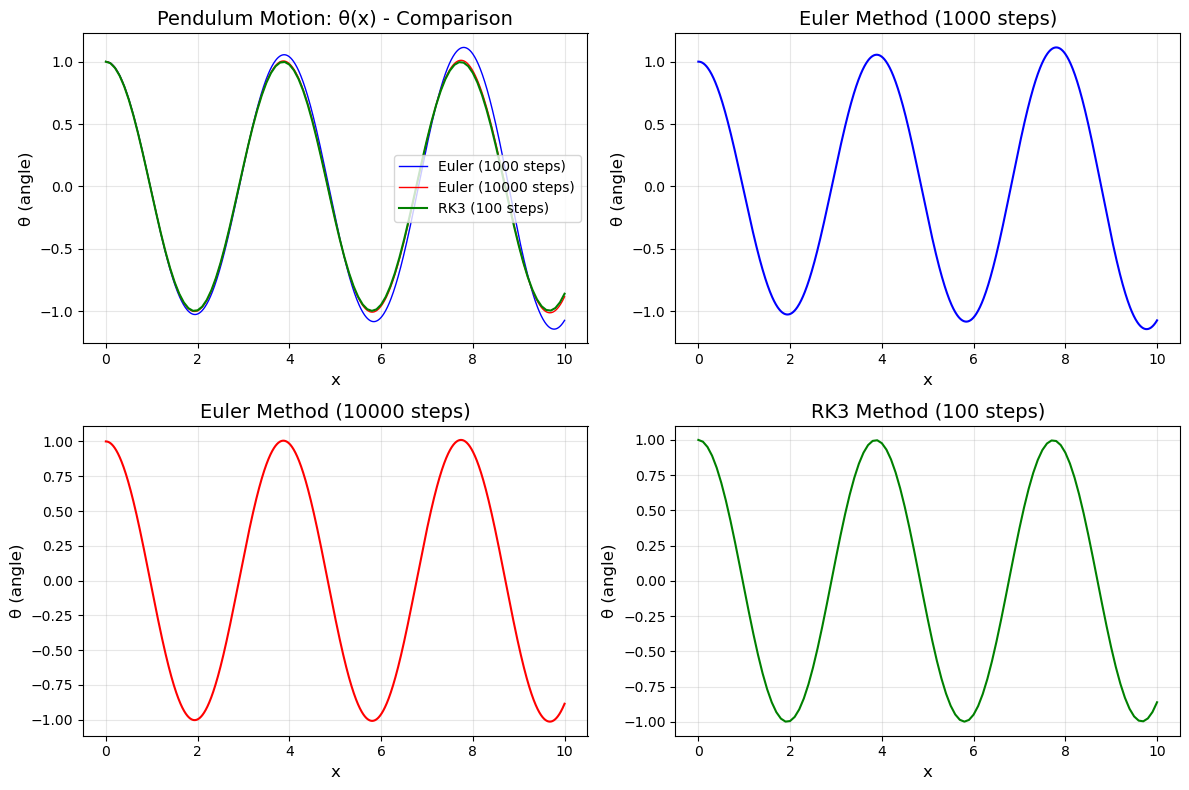

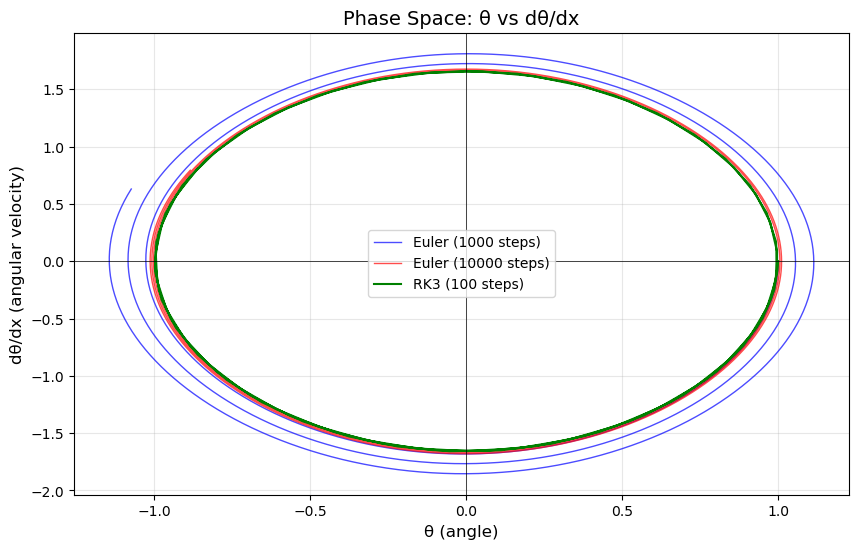


ENERGY ANALYSIS

Energy at x=0: -1.6209069176

Energy drift (final - initial):
  Euler (1000 steps):  3.8953093060e-01
  Euler (10000 steps): 3.5536606243e-02
  RK3 (100 steps):     -7.7732647207e-03


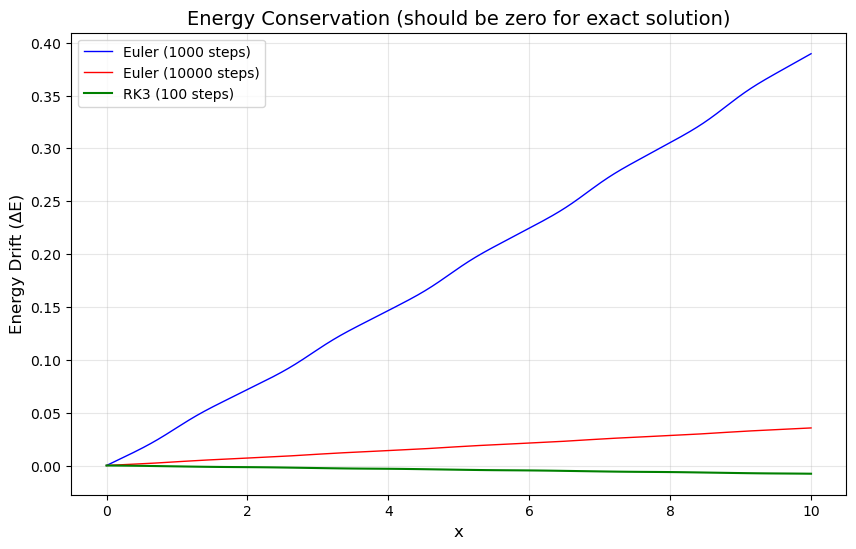


Exercise 13 (Pendulum ODE) Completed!


In [1]:
"""
exercise5.py - Exercise 13: Pendulum ODE Solution

Pendulum equation: d²θ/dx² + 3*sin(θ) = 0
Initial conditions: θ(0) = 1, dθ/dx(0) = 0

Solving using:
- Euler method with 1000 steps
- Euler method with 10000 steps  
- RK3 method with 100 steps

Author: [Your Name]
Date: [Current Date]
"""

import numpy as np
import matplotlib.pyplot as plt

# ============================================
# FORWARD EULER METHOD
# ============================================
def forward_euler(f_ode, xRange, yInitial, numSteps):
    """
    Forward Euler method for ODEs and systems.
    """
    x = np.zeros(numSteps + 1)
    y = np.zeros((numSteps + 1, np.size(yInitial)))
    dx = (xRange[1] - xRange[0]) / numSteps
    
    for k in range(0, numSteps + 1):
        if k == 0:
            x[0] = xRange[0]
            y[0, :] = yInitial
        else:
            x[k] = x[k - 1] + dx
            y[k, :] = y[k - 1, :] + dx * f_ode(x[k - 1], y[k - 1, :])
    
    return x, y


# ============================================
# RK3 METHOD
# ============================================
def rk3(f_ode, xRange, yInitial, numSteps):
    """
    3rd order Runge-Kutta method (RK3) for ODEs and systems.
    """
    x = np.zeros(numSteps + 1)
    y = np.zeros((numSteps + 1, np.size(yInitial)))
    dx = (xRange[1] - xRange[0]) / numSteps
    
    for k in range(0, numSteps + 1):
        if k == 0:
            x[0] = xRange[0]
            y[0, :] = yInitial
        else:
            # First intermediate point (midpoint)
            xa = x[k-1] + dx/2
            ya = y[k-1, :] + (dx/2) * f_ode(x[k-1], y[k-1, :])
            
            # Second intermediate point (endpoint with correction)
            xb = x[k-1] + dx
            yb = y[k-1, :] + dx * (2*f_ode(xa, ya) - f_ode(x[k-1], y[k-1, :]))
            
            # Final step using weighted average
            x[k] = x[k-1] + dx
            y[k, :] = y[k-1, :] + (dx/6) * (
                f_ode(x[k-1], y[k-1, :]) + 
                4*f_ode(xa, ya) + 
                f_ode(xb, yb)
            )
    
    return x, y


# ============================================
# PENDULUM ODE
# ============================================
def pendulum_ode(x, y):
    """
    Pendulum ODE system:
    dy0/dx = y1
    dy1/dx = -3 * sin(y0)
    """
    dy0 = y[1]
    dy1 = -3.0 * np.sin(y[0])
    return np.array([dy0, dy1])


# ============================================
# MAIN CODE
# ============================================

# Problem parameters
xRange = np.array([0.0, 10.0])      # Solve from x=0 to x=10
yInitial = np.array([1.0, 0.0])     # θ(0)=1, dθ/dx(0)=0

print("="*80)
print("EXERCISE 13: PENDULUM ODE")
print("Equation: d²θ/dx² + 3*sin(θ) = 0")
print(f"Initial conditions: θ(0) = {yInitial[0]}, dθ/dx(0) = {yInitial[1]}")
print(f"Solution interval: x ∈ [{xRange[0]}, {xRange[1]}]")
print("="*80)

# ============================================
# Generate solutions
# ============================================

print("\nGenerating solutions...")

# Solution 1: Euler with 1000 steps
print("  - Euler method with 1000 steps")
x1, y1 = forward_euler(pendulum_ode, xRange, yInitial, 1000)

# Solution 2: Euler with 10000 steps
print("  - Euler method with 10000 steps")
x2, y2 = forward_euler(pendulum_ode, xRange, yInitial, 10000)

# Solution 3: RK3 with 100 steps
print("  - RK3 method with 100 steps")
x3, y3 = rk3(pendulum_ode, xRange, yInitial, 100)

print("Done!\n")

# Extract theta (angle) from solutions
theta1 = y1[:, 0] if y1.ndim > 1 else y1
theta2 = y2[:, 0] if y2.ndim > 1 else y2
theta3 = y3[:, 0] if y3.ndim > 1 else y3

# ============================================
# Print final values
# ============================================

print("="*80)
print("FINAL VALUES AT x = 10.0")
print("="*80)
print(f"\nEuler (1000 steps):  θ(10) = {theta1[-1]:.10f}")
print(f"Euler (10000 steps): θ(10) = {theta2[-1]:.10f}")
print(f"RK3 (100 steps):     θ(10) = {theta3[-1]:.10f}")

# ============================================
# PLOTTING
# ============================================

print("\nGenerating plots...")

# Figure 1: All three solutions together
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(x1, theta1, 'b-', linewidth=1, label=f'Euler (1000 steps)')
plt.plot(x2, theta2, 'r-', linewidth=1, label=f'Euler (10000 steps)')
plt.plot(x3, theta3, 'g-', linewidth=1.5, label=f'RK3 (100 steps)')
plt.xlabel('x', fontsize=12)
plt.ylabel('θ (angle)', fontsize=12)
plt.title('Pendulum Motion: θ(x) - Comparison', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Figure 2: Euler 1000 steps only
plt.subplot(2, 2, 2)
plt.plot(x1, theta1, 'b-', linewidth=1.5)
plt.xlabel('x', fontsize=12)
plt.ylabel('θ (angle)', fontsize=12)
plt.title('Euler Method (1000 steps)', fontsize=14)
plt.grid(True, alpha=0.3)

# Figure 3: Euler 10000 steps only
plt.subplot(2, 2, 3)
plt.plot(x2, theta2, 'r-', linewidth=1.5)
plt.xlabel('x', fontsize=12)
plt.ylabel('θ (angle)', fontsize=12)
plt.title('Euler Method (10000 steps)', fontsize=14)
plt.grid(True, alpha=0.3)

# Figure 4: RK3 100 steps only
plt.subplot(2, 2, 4)
plt.plot(x3, theta3, 'g-', linewidth=1.5)
plt.xlabel('x', fontsize=12)
plt.ylabel('θ (angle)', fontsize=12)
plt.title('RK3 Method (100 steps)', fontsize=14)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pendulum_solutions.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# Phase Space Plot (θ vs dθ/dx)
# ============================================

plt.figure(figsize=(10, 6))

# Extract angular velocity
omega1 = y1[:, 1] if y1.ndim > 1 else np.zeros_like(theta1)
omega2 = y2[:, 1] if y2.ndim > 1 else np.zeros_like(theta2)
omega3 = y3[:, 1] if y3.ndim > 1 else np.zeros_like(theta3)

plt.plot(theta1, omega1, 'b-', linewidth=1, alpha=0.7, label=f'Euler (1000 steps)')
plt.plot(theta2, omega2, 'r-', linewidth=1, alpha=0.7, label=f'Euler (10000 steps)')
plt.plot(theta3, omega3, 'g-', linewidth=1.5, label=f'RK3 (100 steps)')
plt.xlabel('θ (angle)', fontsize=12)
plt.ylabel('dθ/dx (angular velocity)', fontsize=12)
plt.title('Phase Space: θ vs dθ/dx', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='k', linewidth=0.5)
plt.savefig('pendulum_phase_space.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# Energy Analysis
# ============================================

print("\n" + "="*80)
print("ENERGY ANALYSIS")
print("="*80)

# Energy for pendulum: E = (1/2)*v² + (1-cos(θ))*3? 
# Actually: d²θ/dx² + 3*sin(θ) = 0
# Multiply by dθ/dx and integrate: (1/2)*(dθ/dx)² - 3*cos(θ) = constant
# So E = 0.5 * (dθ/dx)² - 3*cos(θ)

energy1 = 0.5 * omega1**2 - 3 * np.cos(theta1)
energy2 = 0.5 * omega2**2 - 3 * np.cos(theta2)
energy3 = 0.5 * omega3**2 - 3 * np.cos(theta3)

print(f"\nEnergy at x=0: {0.5*0**2 - 3*np.cos(1.0):.10f}")
print(f"\nEnergy drift (final - initial):")
print(f"  Euler (1000 steps):  {energy1[-1] - energy1[0]:.10e}")
print(f"  Euler (10000 steps): {energy2[-1] - energy2[0]:.10e}")
print(f"  RK3 (100 steps):     {energy3[-1] - energy3[0]:.10e}")

# Plot energy drift
plt.figure(figsize=(10, 6))
plt.plot(x1, energy1 - energy1[0], 'b-', linewidth=1, label=f'Euler (1000 steps)')
plt.plot(x2, energy2 - energy2[0], 'r-', linewidth=1, label=f'Euler (10000 steps)')
plt.plot(x3, energy3 - energy3[0], 'g-', linewidth=1.5, label=f'RK3 (100 steps)')
plt.xlabel('x', fontsize=12)
plt.ylabel('Energy Drift (ΔE)', fontsize=12)
plt.title('Energy Conservation (should be zero for exact solution)', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.savefig('pendulum_energy_drift.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("Exercise 13 (Pendulum ODE) Completed!")
print("="*80)